In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.models import Sequential




In [73]:
data=pd.read_csv("94_character_TMNIST.csv")
data.head()




,names,labels,1,2,3,4,5,6,7,8,...,775,776,777,778,779,780,781,782,783,784
0,Salsa-Regular,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,MouseMemoirs-Regular,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Creepster-Regular,f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SeoulNamsan-Light,/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,HachiMaruPop-Regular,F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
num_classes= data["labels"].nunique()
# print the number of unique classes in the "labels" column to define the number of neurons in the output layer of the ANN model
print(num_classes)
print(data["labels"].unique())



94
<StringArray>
['6', 'D', 'f', '/', 'F', 'x', 'J', '8', 'H', 'k', '@', '1', '=', 'g', ')',
 '2', 'd', '^', '3', 't', '#', '.', '4', 'o', '"', 'y', 'A', 'u', 'G', '-',
 'm', 'W', '&', 'c', '9', 'N', ']', 'P', 'X', '|', '}', 'h', '7', 'j', '5',
 '>', '?', 'b', '*', 'w', 'l', '0', '$', 'I', 'Y', '%', ':', 'T', 'K', 'E',
 '<', 'V', '{', 'M', 'S', 'a', 'i', 'r', ''', 'p', ';', '[', '+', 'e', 'U',
 '(', 's', '~', ',', 'C', 'q', '_', 'n', 'B', 'z', 'v', 'O', 'R', '`', 'Z',
 'Q', 'L', '!', '\']
Length: 94, dtype: str


In [75]:
# to drop names and labels when we use axis=1 to drop columns instead of rows 
x= data.drop(["names","labels"],axis=1)
y=data["labels"]

In [76]:
encoder = LabelEncoder()
target_encoded= encoder.fit_transform(y)



In [77]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,target_encoded,test_size=0.2,random_state=42)


normalization using min_max 

In [78]:
x_train=x_train /255.0
x_test=x_test /255.0

In [79]:
model=Sequential([
    Input(shape=(784,)),
    Dense(512,activation="relu"),
   
    Dense(128,activation="relu"),
 
 Dense(32,activation="relu"),

    Dense(num_classes,activation="softmax")
])


In [80]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])


In [81]:

r = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    batch_size=128,
    
)

Epoch 1/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7872 - loss: 0.8065 - val_accuracy: 0.8576 - val_loss: 0.4906
Epoch 2/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8652 - loss: 0.4362 - val_accuracy: 0.8702 - val_loss: 0.4310
Epoch 3/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8813 - loss: 0.3686 - val_accuracy: 0.8776 - val_loss: 0.3941
Epoch 4/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8930 - loss: 0.3242 - val_accuracy: 0.8872 - val_loss: 0.3611
Epoch 5/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9017 - loss: 0.2927 - val_accuracy: 0.8953 - val_loss: 0.3433
Epoch 6/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9097 - loss: 0.2665 - val_accuracy: 0.8929 - val_loss: 0.3426
Epoch 7/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9148 - loss: 0.2450 - val_accuracy: 0.9009 - val_loss: 0.3288
Epoch 8/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9217 - loss: 0.2272 - 

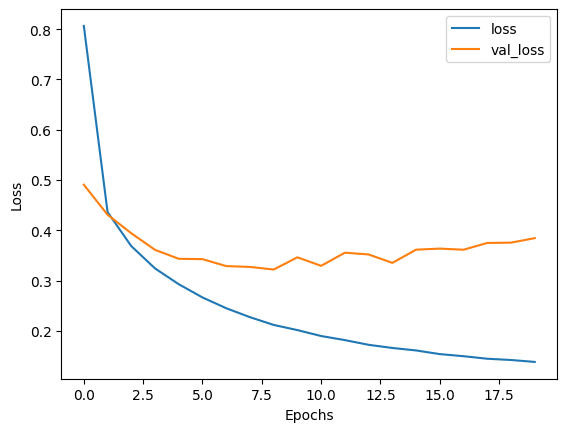

In [82]:
plt.plot(r.history["loss"],label="loss")
plt.plot(r.history["val_loss"],label="val_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



In [83]:
print(model.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 94)             │         3,102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,424,444 (5.43 MB)

 Trainable params: 474,814 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 949,630 (3.62 MB)

None


In [84]:
print(model.evaluate(x_test,y_test))

1714/1714 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9122 - loss: 0.3844
[0.3843667209148407, 0.9121654629707336]


save model 

In [85]:
model.save("tmnist_model.keras")

In [86]:
import joblib
joblib.dump(encoder,"tmnist_encoder.joblib")



['tmnist_encoder.joblib']